# Home task: Tensorflow keras

## 1. Import Libraries

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## 2. Load the dataset


In [74]:
def load_dataset():
    fn = 'supplementary_data/train_signs.h5'
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:])
    Y_train = np.array(train_dataset["train_set_y"][:])

    fn = 'supplementary_data/test_signs.h5'
    test_dataset = h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:])
    Y_test = np.array(test_dataset["test_set_y"][:])

    classes = np.array(test_dataset["list_classes"][:])

    Y_train = Y_train.reshape((1, Y_train.shape[0]))
    Y_test = Y_test.reshape((1, Y_test.shape[0]))

    return X_train, Y_train, X_test, Y_test, classes


train_data, train_labels, test_data, test_labels, classes = load_dataset()

print('train_data.shape=', train_data.shape)
print('train_labels.shape=', train_labels.shape)
print('test_data.shape=', test_data.shape)
print('test_labels.shape=', test_labels.shape)
print('classes=', classes)

train_data.shape= (1080, 64, 64, 3)
train_labels.shape= (1, 1080)
test_data.shape= (120, 64, 64, 3)
test_labels.shape= (1, 120)
classes= [0 1 2 3 4 5]


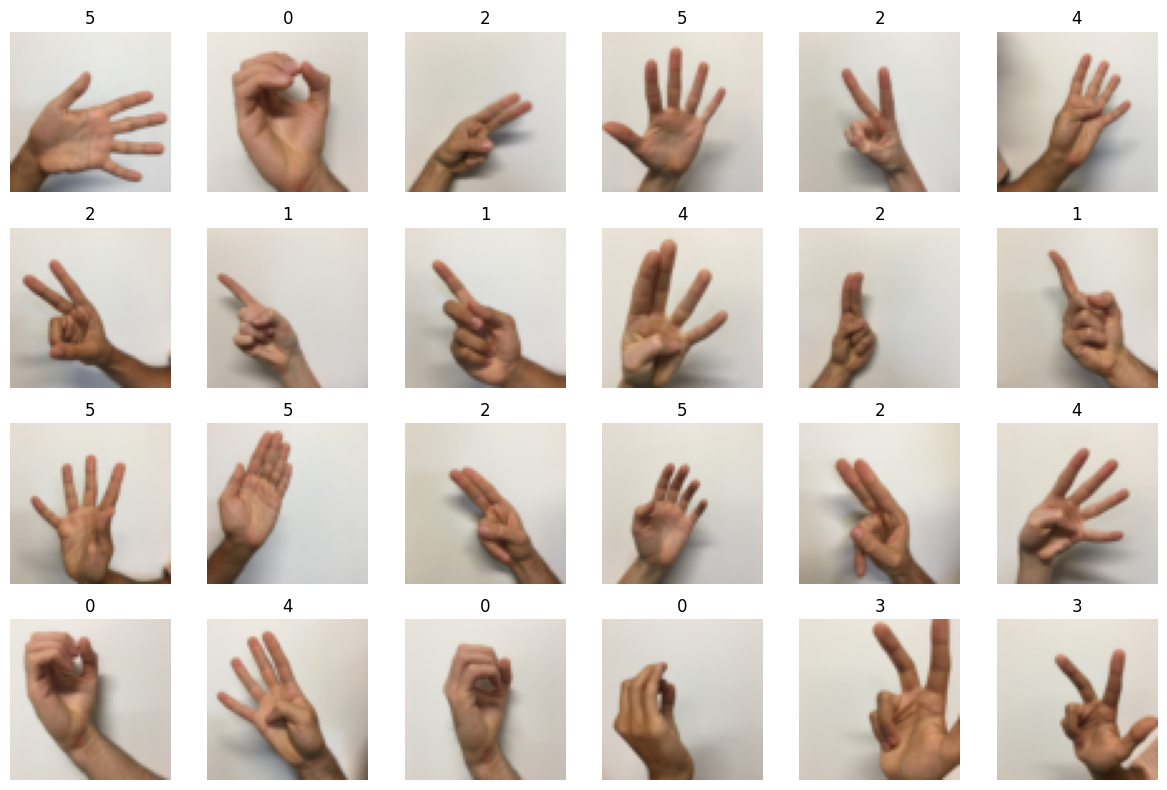

In [75]:
plt.figure(figsize=(12, 8))

for i in range(24):
    ax = plt.subplot(4, 6, i + 1)
    ax.imshow(train_data[i])
    ax.set_title(str(train_labels[0, i]))
    ax.axis('off')

plt.tight_layout(h_pad=1, w_pad=1)

## 3. Process the data


In [76]:
np.random.seed(1)
tf.random.set_seed(1)

X_train = train_data.astype('float32') / 255
X_test = test_data.astype('float32') / 255

Y_train = train_labels.reshape(-1)
Y_test = test_labels.reshape(-1)

nClasses = len(classes)

Y_train_one_hot = to_categorical(Y_train, nClasses)
Y_test_one_hot = to_categorical(Y_test, nClasses)

print('X_train.shape=', X_train.shape)
print('X_test.shape=', X_test.shape)
print('Y_train_one_hot.shape=', Y_train_one_hot.shape)
print('Y_test_one_hot.shape=', Y_test_one_hot.shape)
print('Number of classes=', nClasses)

X_train.shape= (1080, 64, 64, 3)
X_test.shape= (120, 64, 64, 3)
Y_train_one_hot.shape= (1080, 6)
Y_test_one_hot.shape= (120, 6)
Number of classes= 6


## 4. Build helper functions


In [77]:
def create_model(hidden_layers=[128], activation='relu', dropout_ratio=0.3):
    model = Sequential()

    model.add(Conv2D(32, (3, 3), activation=activation, padding='same', input_shape=(64, 64, 3)))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(64, (3, 3), activation=activation, padding='same'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(128, (3, 3), activation=activation, padding='same'))
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())

    for units in hidden_layers:
        model.add(Dense(units, activation=activation))

        if dropout_ratio > 0:
            model.add(Dropout(dropout_ratio))

    model.add(Dense(nClasses, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [78]:
def plot_history(history, title):
    plt.figure(figsize=[8, 6])
    plt.plot(history.history['loss'], 'r', linewidth=3.0)
    plt.plot(history.history['val_loss'], 'b', linewidth=3.0)
    plt.legend(['Training loss', 'Validation Loss'], fontsize=14)
    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.title(title + ' - Loss Curves', fontsize=16)
    plt.show()

    plt.figure(figsize=[8, 6])
    plt.plot(history.history['accuracy'], 'r', linewidth=3.0)
    plt.plot(history.history['val_accuracy'], 'b', linewidth=3.0)
    plt.legend(['Training Accuracy', 'Validation Accuracy'], fontsize=14)
    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Accuracy', fontsize=14)
    plt.title(title + ' - Accuracy Curves', fontsize=16)
    plt.show()

In [79]:
def get_callbacks():
    return [
        EarlyStopping(
            monitor='val_accuracy',
            mode='max',
            patience=8,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            mode='min',
            factor=0.5,
            patience=3
        )
    ]

## 5. Model 1: basic model with ReLU

The first model uses ReLU activation and one Dense hidden layer after convolutional layers.

In [80]:
model_relu = create_model(
    hidden_layers=[128],
    activation='relu',
    dropout_ratio=0.3
)

model_relu.summary()

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,726 (4.36 MB)

 Trainable params: 1,142,726 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
history_relu = model_relu.fit(
    X_train,
    Y_train_one_hot,
    batch_size=32,
    epochs=40,
    verbose=1,
    validation_data=(X_test, Y_test_one_hot),
    callbacks=get_callbacks()
)

Epoch 1/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.1676 - loss: 1.8013 - val_accuracy: 0.4167 - val_loss: 1.7842 - learning_rate: 0.0010
Epoch 2/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.2880 - loss: 1.7012 - val_accuracy: 0.3667 - val_loss: 1.5829 - learning_rate: 0.0010
Epoch 3/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.5065 - loss: 1.3203 - val_accuracy: 0.6583 - val_loss: 1.0200 - learning_rate: 0.0010
Epoch 4/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.6667 - loss: 0.9594 - val_accuracy: 0.7583 - val_loss: 0.7620 - learning_rate: 0.0010
Epoch 5/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.7407 - loss: 0.7061 - val_accuracy: 0.8167 - val_loss: 0.5709 - learning_rate: 0.0010
Epoch 6/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7852 - loss: 0.5766 - val_accuracy: 0.8583 - val_loss: 0.4519 - learning_rate: 0.0010
Epoch 7/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.8537 - loss: 0.4292 - val_acc

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9750 - loss: 0.1177
ReLU model result on Test Data : Loss = 0.11769992858171463, accuracy = 0.9750000238418579


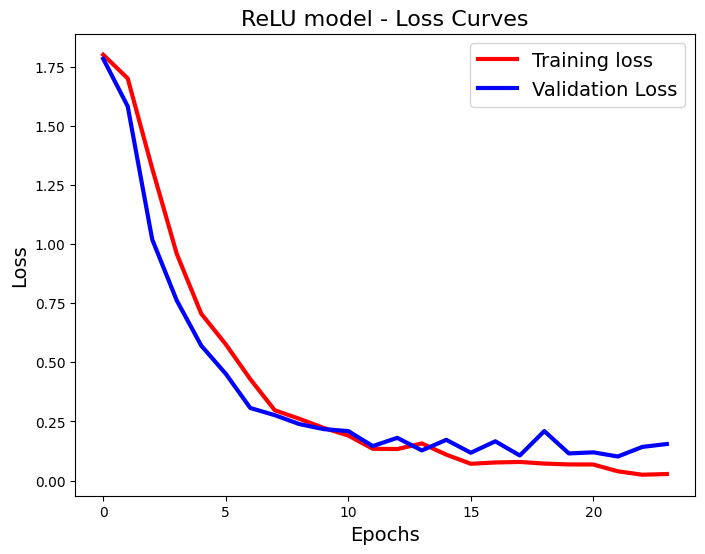

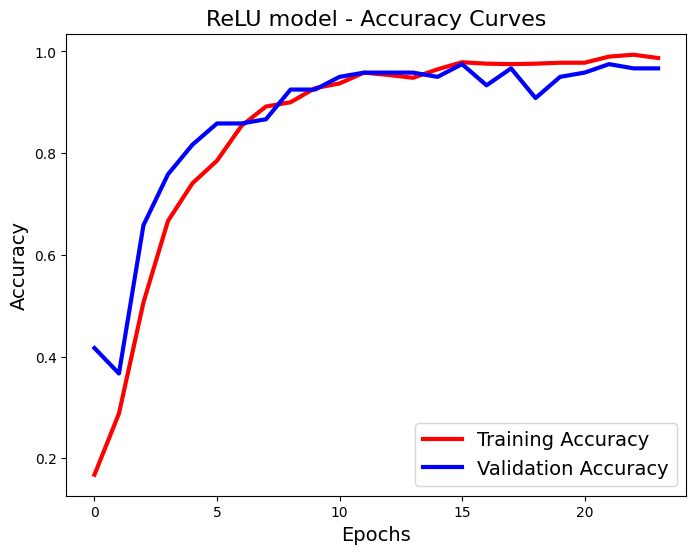

In [82]:
test_loss, test_acc = model_relu.evaluate(X_test, Y_test_one_hot)

print("ReLU model result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

plot_history(history_relu, 'ReLU model')

## 6. Model 2: change activation to tanh

In this experiment, I use the same number of hidden layers, but change the activation function to `tanh`.

In [83]:
model_tanh = create_model(
    hidden_layers=[128],
    activation='tanh',
    dropout_ratio=0.3
)

model_tanh.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_45 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,726 (4.36 MB)

 Trainable params: 1,142,726 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
history_tanh = model_tanh.fit(
    X_train,
    Y_train_one_hot,
    batch_size=32,
    epochs=40,
    verbose=1,
    validation_data=(X_test, Y_test_one_hot),
    callbacks=get_callbacks()
)

Epoch 1/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.3083 - loss: 1.9187 - val_accuracy: 0.5667 - val_loss: 1.2060 - learning_rate: 0.0010
Epoch 2/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.6343 - loss: 1.0213 - val_accuracy: 0.7583 - val_loss: 0.8055 - learning_rate: 0.0010
Epoch 3/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.8120 - loss: 0.6197 - val_accuracy: 0.8417 - val_loss: 0.5041 - learning_rate: 0.0010
Epoch 4/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.8556 - loss: 0.4196 - val_accuracy: 0.8917 - val_loss: 0.3693 - learning_rate: 0.0010
Epoch 5/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.9065 - loss: 0.2989 - val_accuracy: 0.9083 - val_loss: 0.2890 - learning_rate: 0.0010
Epoch 6/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.9269 - loss: 0.2246 - val_accuracy: 0.9500 - val_loss: 0.2203 - learning_rate: 0.0010
Epoch 7/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9565 - loss: 0.1598 - val_acc

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9750 - loss: 0.1343
Tanh model result on Test Data : Loss = 0.13433963060379028, accuracy = 0.9750000238418579


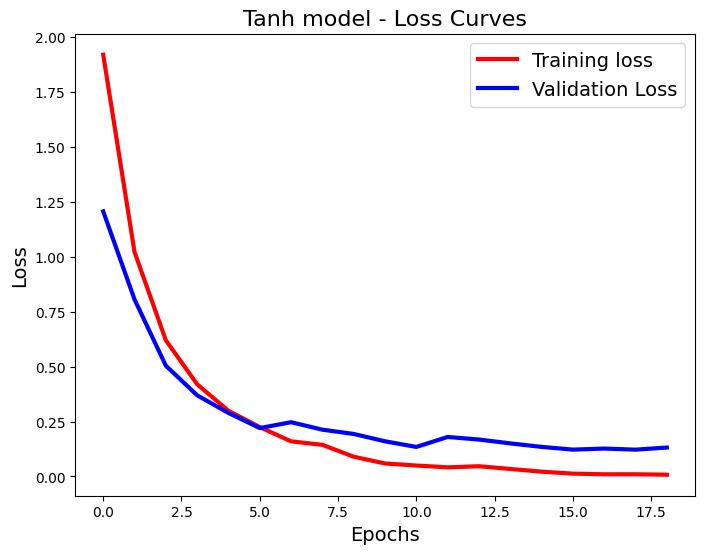

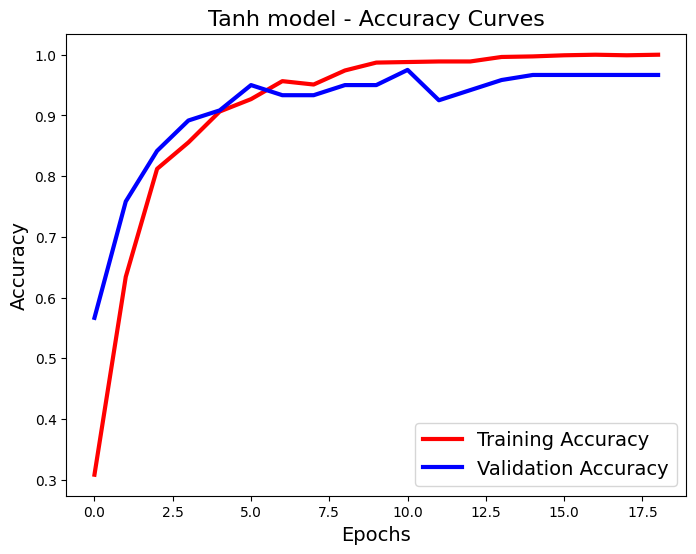

In [85]:
test_loss, test_acc = model_tanh.evaluate(X_test, Y_test_one_hot)

print("Tanh model result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

plot_history(history_tanh, 'Tanh model')

## 7. Model 3: change activation to sigmoid

In this experiment, I use `sigmoid` activation and compare it with ReLU and tanh.

In [86]:
model_sigmoid = create_model(
    hidden_layers=[128],
    activation='sigmoid',
    dropout_ratio=0.3
)

model_sigmoid.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,726 (4.36 MB)

 Trainable params: 1,142,726 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
history_sigmoid = model_sigmoid.fit(
    X_train,
    Y_train_one_hot,
    batch_size=32,
    epochs=40,
    verbose=1,
    validation_data=(X_test, Y_test_one_hot),
    callbacks=get_callbacks()
)

Epoch 1/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.1815 - loss: 2.2658 - val_accuracy: 0.1667 - val_loss: 1.8469 - learning_rate: 0.0010
Epoch 2/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.1657 - loss: 1.9459 - val_accuracy: 0.1667 - val_loss: 1.7931 - learning_rate: 0.0010
Epoch 3/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.1565 - loss: 1.9254 - val_accuracy: 0.1667 - val_loss: 1.8005 - learning_rate: 0.0010
Epoch 4/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.1833 - loss: 1.8829 - val_accuracy: 0.1667 - val_loss: 1.8105 - learning_rate: 0.0010
Epoch 5/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.1676 - loss: 1.8922 - val_accuracy: 0.1667 - val_loss: 1.7921 - learning_rate: 0.0010
Epoch 6/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.1722 - loss: 1.8798 - val_accuracy: 0.1667 - val_loss: 1.7929 - learning_rate: 0.0010
Epoch 7/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.1528 - loss: 1.8999 - val_acc

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1667 - loss: 1.8469
Sigmoid model result on Test Data : Loss = 1.8468537330627441, accuracy = 0.1666666716337204


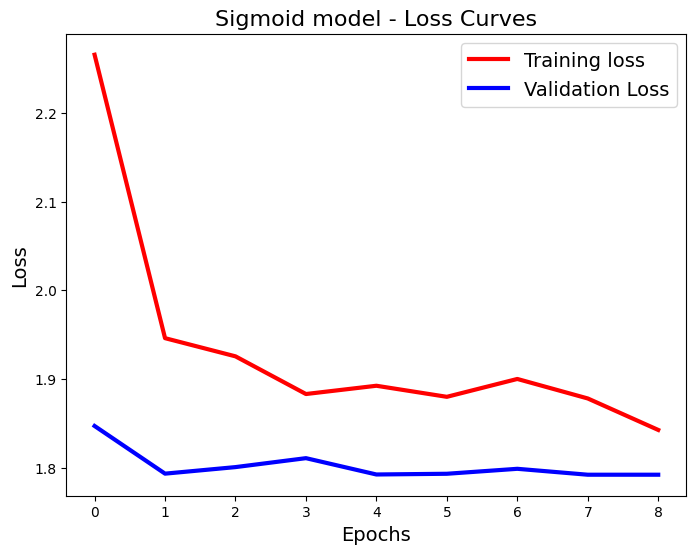

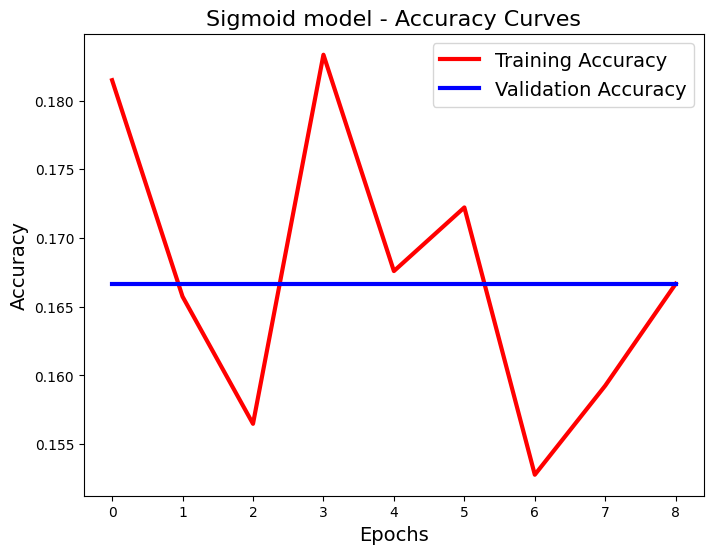

In [88]:
test_loss, test_acc = model_sigmoid.evaluate(X_test, Y_test_one_hot)

print("Sigmoid model result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

plot_history(history_sigmoid, 'Sigmoid model')

## 8. Model 4: change the number of hidden layers

Here I use two Dense hidden layers instead of one.

In [89]:
model_2_hidden = create_model(
    hidden_layers=[128, 64],
    activation='relu',
    dropout_ratio=0.3
)

model_2_hidden.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_51 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,598 (4.39 MB)

 Trainable params: 1,150,598 (4.39 MB)

 Non-trainable params: 0 (0.00 B)

In [91]:
history_2_hidden = model_2_hidden.fit(
    X_train,
    Y_train_one_hot,
    batch_size=32,
    epochs=40,
    verbose=1,
    validation_data=(X_test, Y_test_one_hot),
    callbacks=get_callbacks()
)

Epoch 1/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.1815 - loss: 1.8061 - val_accuracy: 0.2833 - val_loss: 1.7907 - learning_rate: 0.0010
Epoch 2/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.1972 - loss: 1.7845 - val_accuracy: 0.3667 - val_loss: 1.7536 - learning_rate: 0.0010
Epoch 3/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.3343 - loss: 1.6169 - val_accuracy: 0.4167 - val_loss: 1.3712 - learning_rate: 0.0010
Epoch 4/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.4250 - loss: 1.4068 - val_accuracy: 0.6500 - val_loss: 1.1096 - learning_rate: 0.0010
Epoch 5/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.5250 - loss: 1.1900 - val_accuracy: 0.6750 - val_loss: 0.8732 - learning_rate: 0.0010
Epoch 6/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.6454 - loss: 0.9694 - val_accuracy: 0.8083 - val_loss: 0.6934 - learning_rate: 0.0010
Epoch 7/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.6991 - loss: 0.7797 - val_acc

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9167 - loss: 0.2471
Two hidden layers model result on Test Data : Loss = 0.24710281193256378, accuracy = 0.9166666865348816


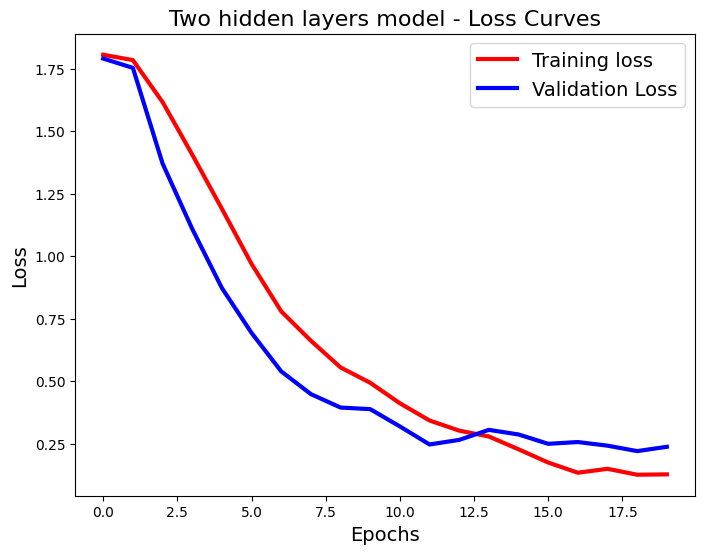

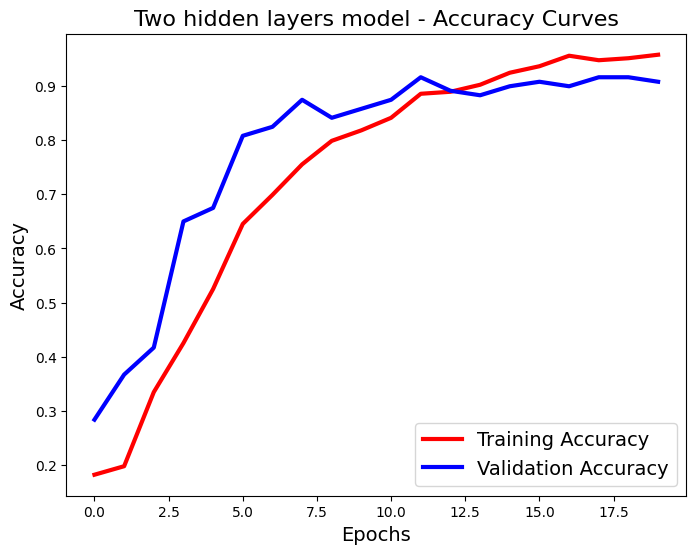

In [112]:
test_loss, test_acc = model_2_hidden.evaluate(X_test, Y_test_one_hot)

print("Two hidden layers model result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

plot_history(history_2_hidden, 'Two hidden layers model')

## 9. Model 5: add Dropout

In this experiment, I add Dropout to reduce overfitting.

In [92]:
model_dropout_05 = create_model(
    hidden_layers=[128],
    activation='relu',
    dropout_ratio=0.5
)

model_dropout_05.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_57 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_59 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,726 (4.36 MB)

 Trainable params: 1,142,726 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [93]:
history_dropout_05 = model_dropout_05.fit(
    X_train,
    Y_train_one_hot,
    batch_size=32,
    epochs=40,
    verbose=1,
    validation_data=(X_test, Y_test_one_hot),
    callbacks=get_callbacks()
)

Epoch 1/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.1926 - loss: 1.7950 - val_accuracy: 0.2250 - val_loss: 1.7429 - learning_rate: 0.0010
Epoch 2/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.3583 - loss: 1.5657 - val_accuracy: 0.4750 - val_loss: 1.3741 - learning_rate: 0.0010
Epoch 3/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.5444 - loss: 1.1963 - val_accuracy: 0.7167 - val_loss: 0.9190 - learning_rate: 0.0010
Epoch 4/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.6583 - loss: 1.0022 - val_accuracy: 0.7917 - val_loss: 0.6944 - learning_rate: 0.0010
Epoch 5/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7519 - loss: 0.7029 - val_accuracy: 0.8500 - val_loss: 0.5013 - learning_rate: 0.0010
Epoch 6/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.7796 - loss: 0.6026 - val_accuracy: 0.8833 - val_loss: 0.4481 - learning_rate: 0.0010
Epoch 7/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.8398 - loss: 0.4967 - val_acc

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9667 - loss: 0.1340
Dropout 0.5 model result on Test Data : Loss = 0.13402090966701508, accuracy = 0.9666666388511658


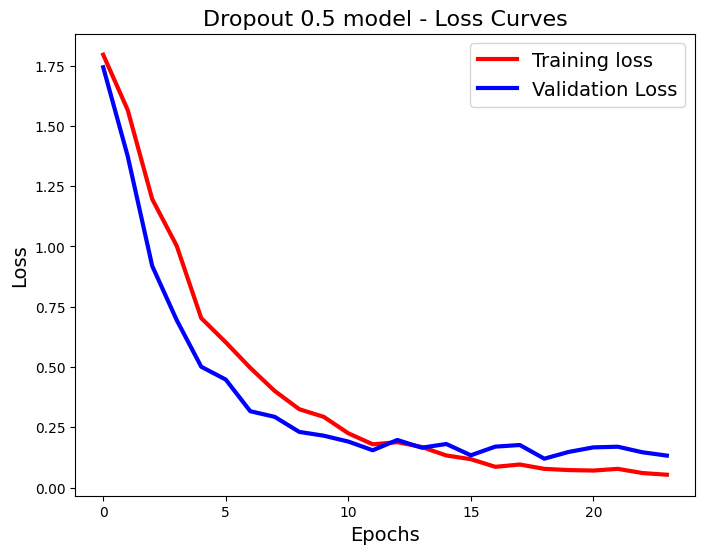

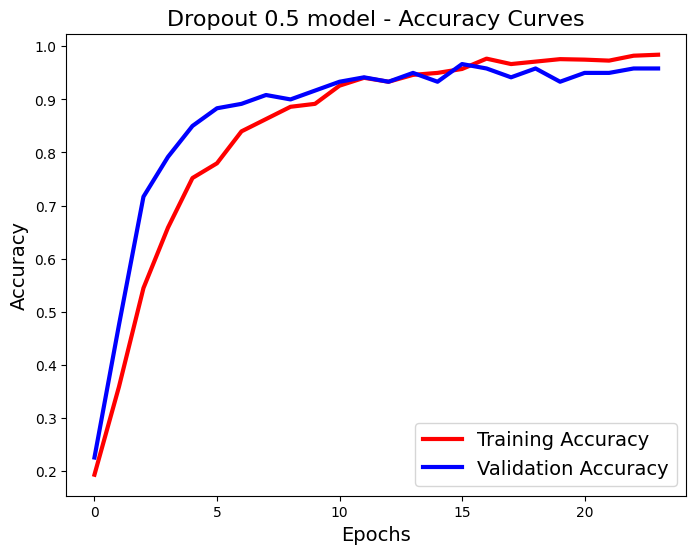

In [94]:
test_loss, test_acc = model_dropout_05.evaluate(X_test, Y_test_one_hot)

print("Dropout 0.5 model result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

plot_history(history_dropout_05, 'Dropout 0.5 model')

## 10. Compare all models

Finally, I compare test loss and test accuracy for all trained models.

In [107]:
results = []

models = {
    'ReLU': model_relu,
    'Tanh': model_tanh,
    'Sigmoid': model_sigmoid,
    'ReLU 2 hidden layers': model_2_hidden,
    'ReLU Dropout 0.5': model_dropout_05
}

for name, model in models.items():
    test_loss, test_acc = model.evaluate(X_test, Y_test_one_hot, verbose=0)
    results.append([name, test_loss, test_acc])

results_df = pd.DataFrame(results, columns=['Model', 'Test Loss', 'Test Accuracy'])
results_df

,Model,Test Loss,Test Accuracy
0,ReLU,0.117700,0.975000
1,Tanh,0.134340,0.975000
2,Sigmoid,1.846854,0.166667
3,ReLU 2 hidden layers,0.247103,0.916667
4,ReLU Dropout 0.5,0.171112,0.958333


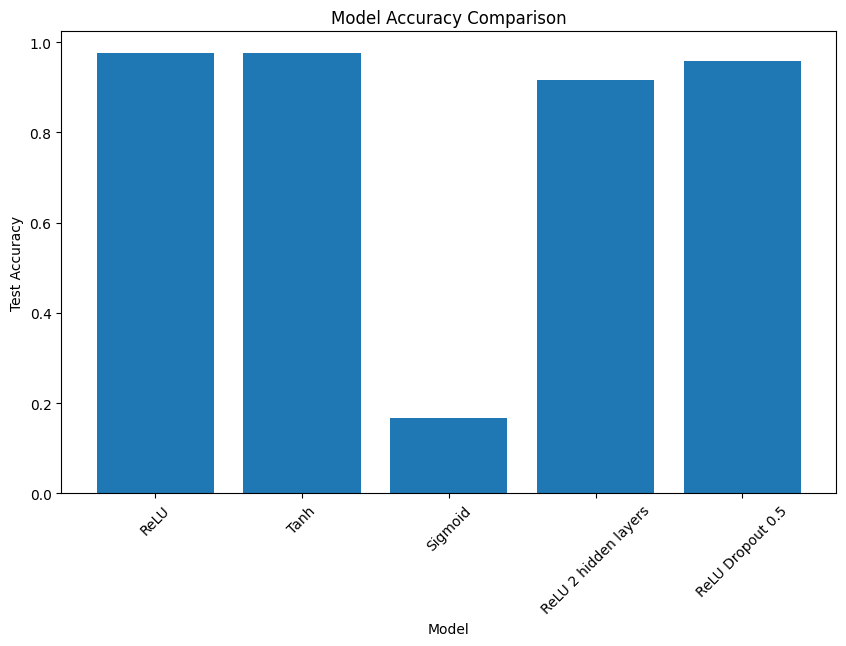

In [108]:
plt.figure(figsize=(10, 6))
plt.bar(results_df['Model'], results_df['Test Accuracy'])
plt.xticks(rotation=45)
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()

## 11. Inference

I use the best trained model to predict classes for test images.

In [109]:
best_model_name = results_df.sort_values(by='Test Accuracy', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]

print('Best model:', best_model_name)

Best model: ReLU


In [110]:
predict_x = best_model.predict(X_test)
predicted_classes = np.argmax(predict_x, axis=1)

predicted_classes[:20]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([0, 0, 0, 5, 1, 0, 3, 1, 5, 1, 5, 1, 3, 1, 1, 3, 5, 4, 0, 4])

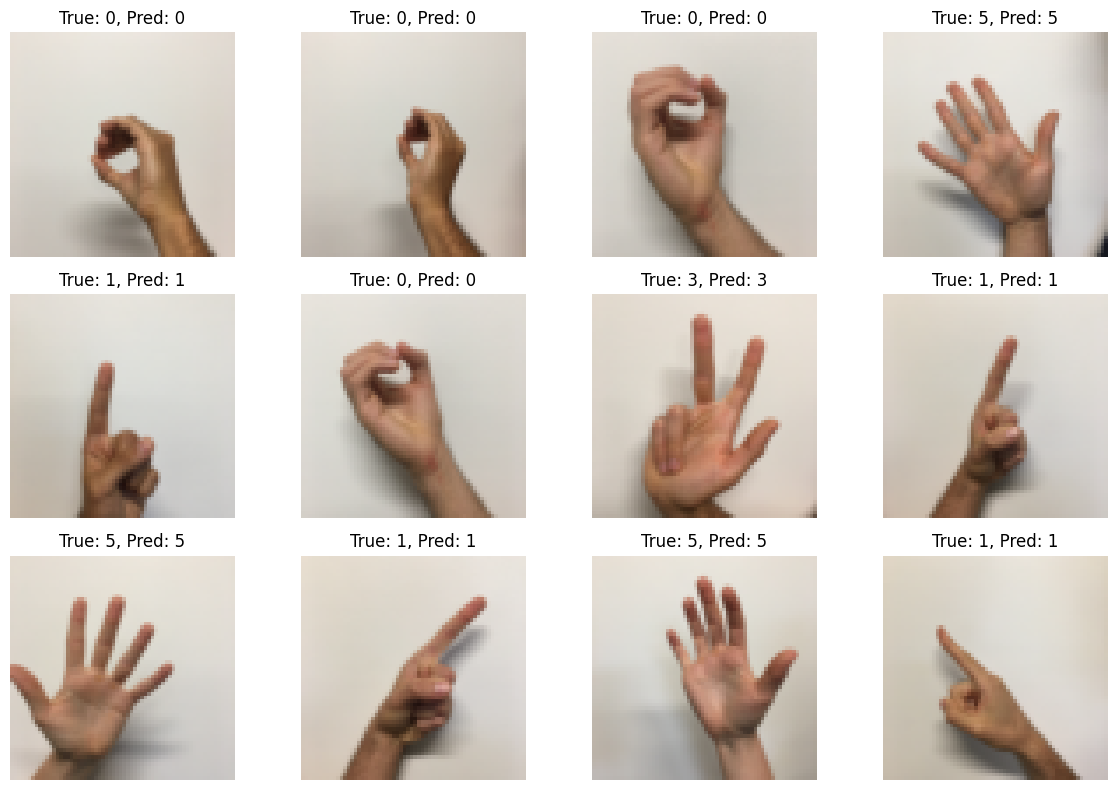

In [111]:
plt.figure(figsize=(12, 8))

for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    ax.imshow(test_data[i])

    true_label = Y_test[i]
    pred_label = predicted_classes[i]

    ax.set_title('True: {}, Pred: {}'.format(true_label, pred_label))
    ax.axis('off')

plt.tight_layout()
plt.show()

## Conclusion

In this work, I classified the signs/fingers dataset using neural networks in Keras.

The dataset was loaded from `.h5` files, images were normalized, and labels were converted to one-hot encoding. Several CNN models were trained and compared. During the experiments, I changed the activation function, the number of hidden layers, and the dropout ratio.

The best results were achieved by models with `ReLU` and `tanh` activation functions. They showed high test accuracy, around 95–97%. The model with two hidden layers also performed well, which means that increasing the number of hidden layers can improve the result if the model is configured correctly.

The model with `Dropout 0.5` also gave a good result. This shows that dropout can help reduce overfitting and keep the model stable. However, the `sigmoid` activation function showed the weakest result, close to random guessing. It was not suitable for this image classification task in the current model configuration.

Overall, CNN models worked much better than a simple feedforward neural network for this dataset, because convolutional layers can extract useful features from images. The best model was selected by the highest test accuracy and was used to predict labels for test images.